# Task 1: Exploring and Visualizing a Simple Dataset
**Internship:** DevelopersHub Corporation – Data Science & Analytics  
**Dataset:** Iris Dataset  
**Objective:** Understand how to read, summarize, and visualize a dataset using pandas, matplotlib, and seaborn.

---
## Problem Statement
The Iris dataset contains measurements of sepal and petal dimensions for three species of iris flowers (*setosa*, *versicolor*, *virginica*). Our goal is to explore the dataset structure, summarize statistics, and create meaningful visualizations to understand patterns in the data.


In [4]:
# ── Import Libraries ──────────────────────────────────────────────────────────
import pandas as pd                 # Data manipulation and analysis
import numpy as np                  # Numerical operations
import matplotlib.pyplot as plt     # Data visualization
import seaborn as sns               # Statistical data visualization

# Set a clean visual style
sns.set_theme(style="whitegrid", palette="Set2")    # Use a pastel color palette
plt.rcParams["figure.dpi"] = 110                    # Set higher resolution for plots


## 1. Load the Dataset

In [5]:
# Load Iris dataset directly from seaborn (no external file needed)
df = sns.load_dataset("iris")           # Load the Iris dataset into a DataFrame

print("Dataset loaded successfully!")   # Confirm that the dataset has been loaded
print(f"Shape: {df.shape}")             # Print the shape of the dataset


Dataset loaded successfully!
Shape: (150, 5)


## 2. Dataset Structure & Inspection

In [6]:
# Display shape, columns, and first 5 rows
print("Shape (rows, columns):", df.shape)       # Print the shape of the dataset
print("\nColumn Names:", df.columns.tolist())   # Print the column names as a list
print("\nData Types:\n", df.dtypes)             # Print the data types of each column


Shape (rows, columns): (150, 5)

Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data Types:
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [7]:
# First 5 rows
df.head()       # Display the first 5 rows of the dataset

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
# Last 5 rows
df.tail()   # Display the last 5 rows of the dataset

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [9]:
# Statistical summary of numeric features
df.describe()   # Display summary statistics for numeric columns

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
# Check for missing values
print("Missing Values per Column:")                         # Print the count of missing values for each column
print(df.isnull().sum())                                    # Calculate and print the total number of missing values in the dataset
print("\nTotal missing values:", df.isnull().sum().sum())   # Calculate and print the total number of missing values across the entire dataset


Missing Values per Column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing values: 0


In [11]:
# Class distribution
print("Species Distribution:")
print(df["species"].value_counts()) # Print the count of each species in the dataset


Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Visualizations

### 3.1 Scatter Plot – Sepal Length vs Sepal Width

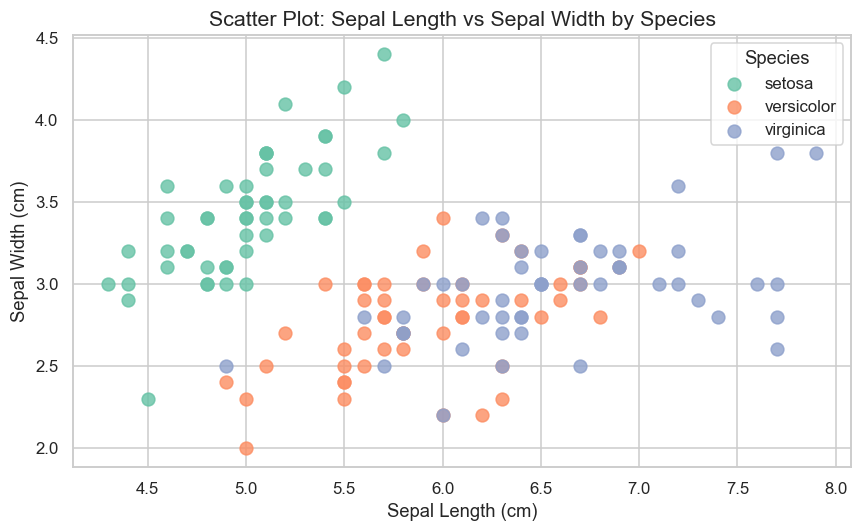

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for species, group in df.groupby("species"):    # Group the data by species and plot each group separately
    # Scatter plot for each species with different colors and some transparency
    ax.scatter(group["sepal_length"], group["sepal_width"], label=species, s=70, alpha=0.8) 

ax.set_xlabel("Sepal Length (cm)", fontsize=12)
ax.set_ylabel("Sepal Width (cm)", fontsize=12)
ax.set_title("Scatter Plot: Sepal Length vs Sepal Width by Species", fontsize=14)
ax.legend(title="Species")
plt.tight_layout()
plt.show()


### 3.2 Scatter Plot – Petal Length vs Petal Width

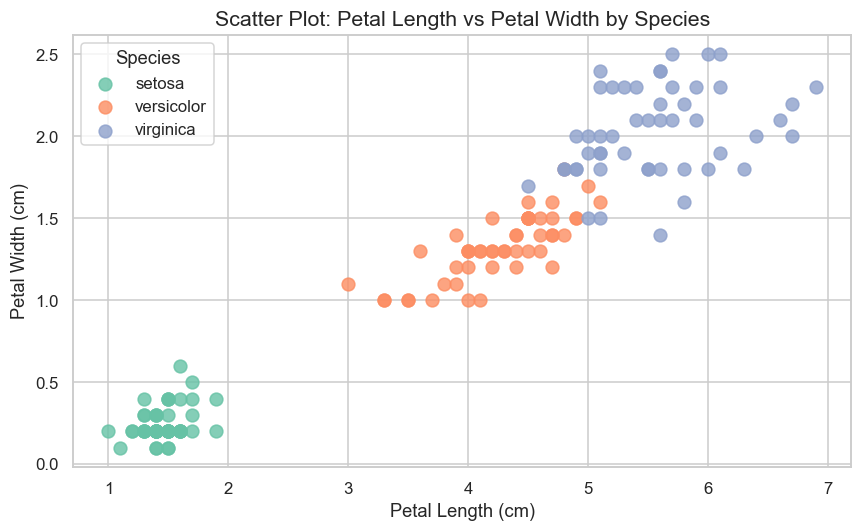

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))          # Create a new figure and axis for the second scatter plot
# Scatter plot for petal length vs petal width, colored by species
for species, group in df.groupby("species"):
    ax.scatter(group["petal_length"], group["petal_width"], label=species, s=70, alpha=0.8)

ax.set_xlabel("Petal Length (cm)", fontsize=12)
ax.set_ylabel("Petal Width (cm)", fontsize=12)
ax.set_title("Scatter Plot: Petal Length vs Petal Width by Species", fontsize=14)
ax.legend(title="Species")
plt.tight_layout()
plt.show()


### 3.3 Histograms – Distribution of Each Feature

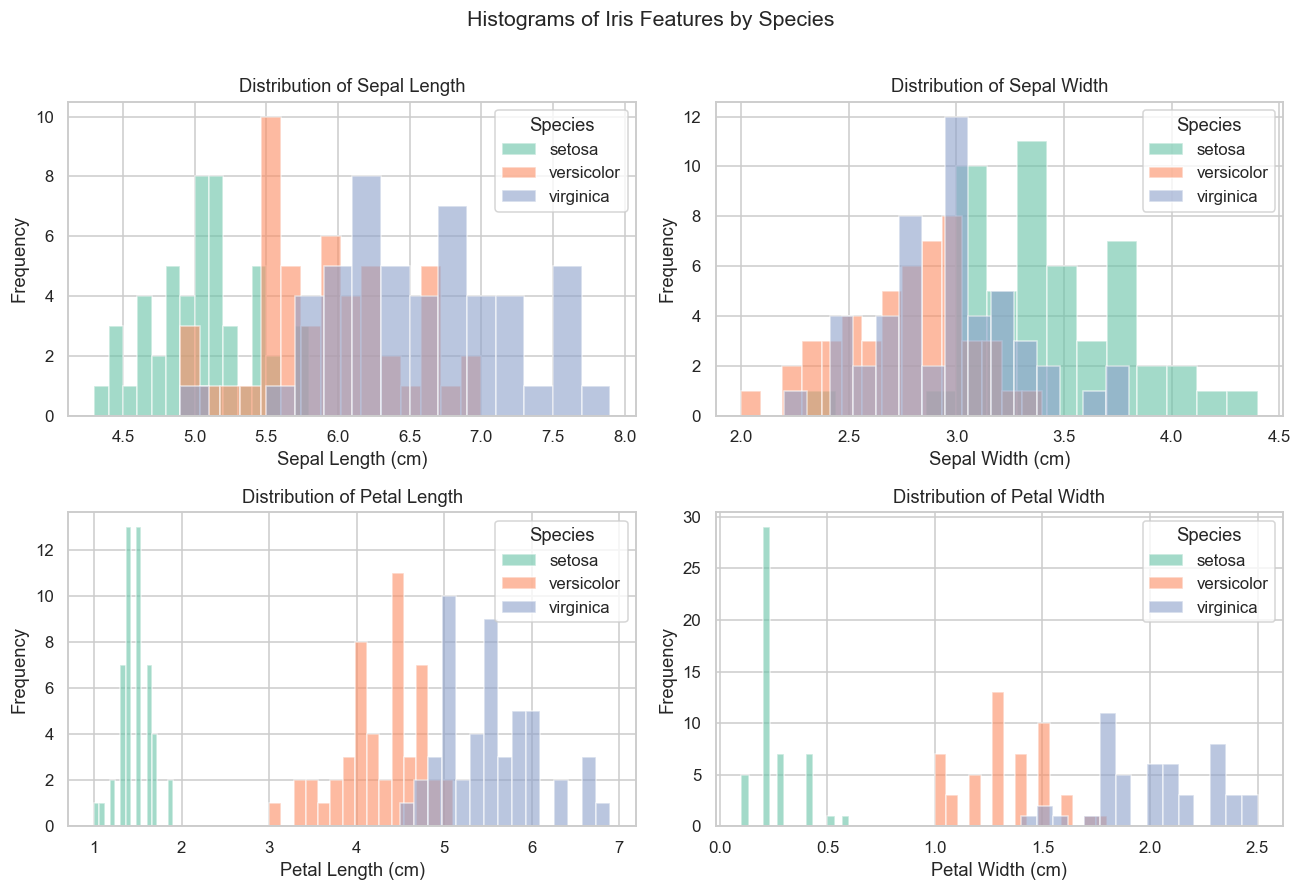

In [12]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    for species, group in df.groupby("species"):
        axes[i].hist(group[feature], bins=15, alpha=0.6, label=species)
    axes[i].set_title(f"Distribution of {feature.replace('_', ' ').title()}", fontsize=12)
    axes[i].set_xlabel(feature.replace("_", " ").title() + " (cm)")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(title="Species")

plt.suptitle("Histograms of Iris Features by Species", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 3.4 Box Plots – Outlier Detection

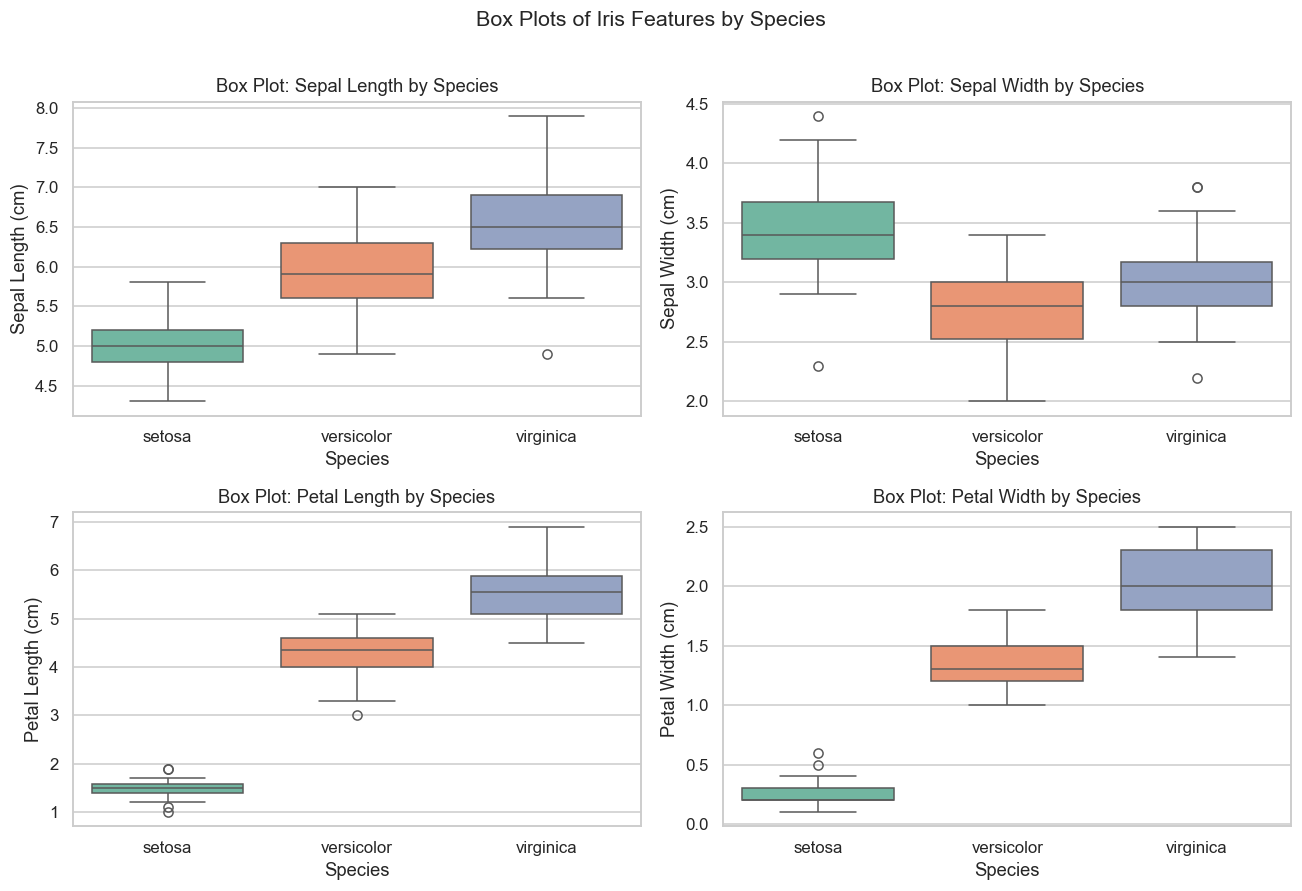

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

for i, feature in enumerate(features):
    sns.boxplot(x="species", y=feature, data=df, ax=axes[i],
                hue="species", palette="Set2", legend=False)  # ← changed
    axes[i].set_title(f"Box Plot: {feature.replace('_', ' ').title()} by Species", fontsize=12)
    axes[i].set_xlabel("Species")
    axes[i].set_ylabel(feature.replace("_", " ").title() + " (cm)")

plt.suptitle("Box Plots of Iris Features by Species", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Pairplot – All Feature Relationships

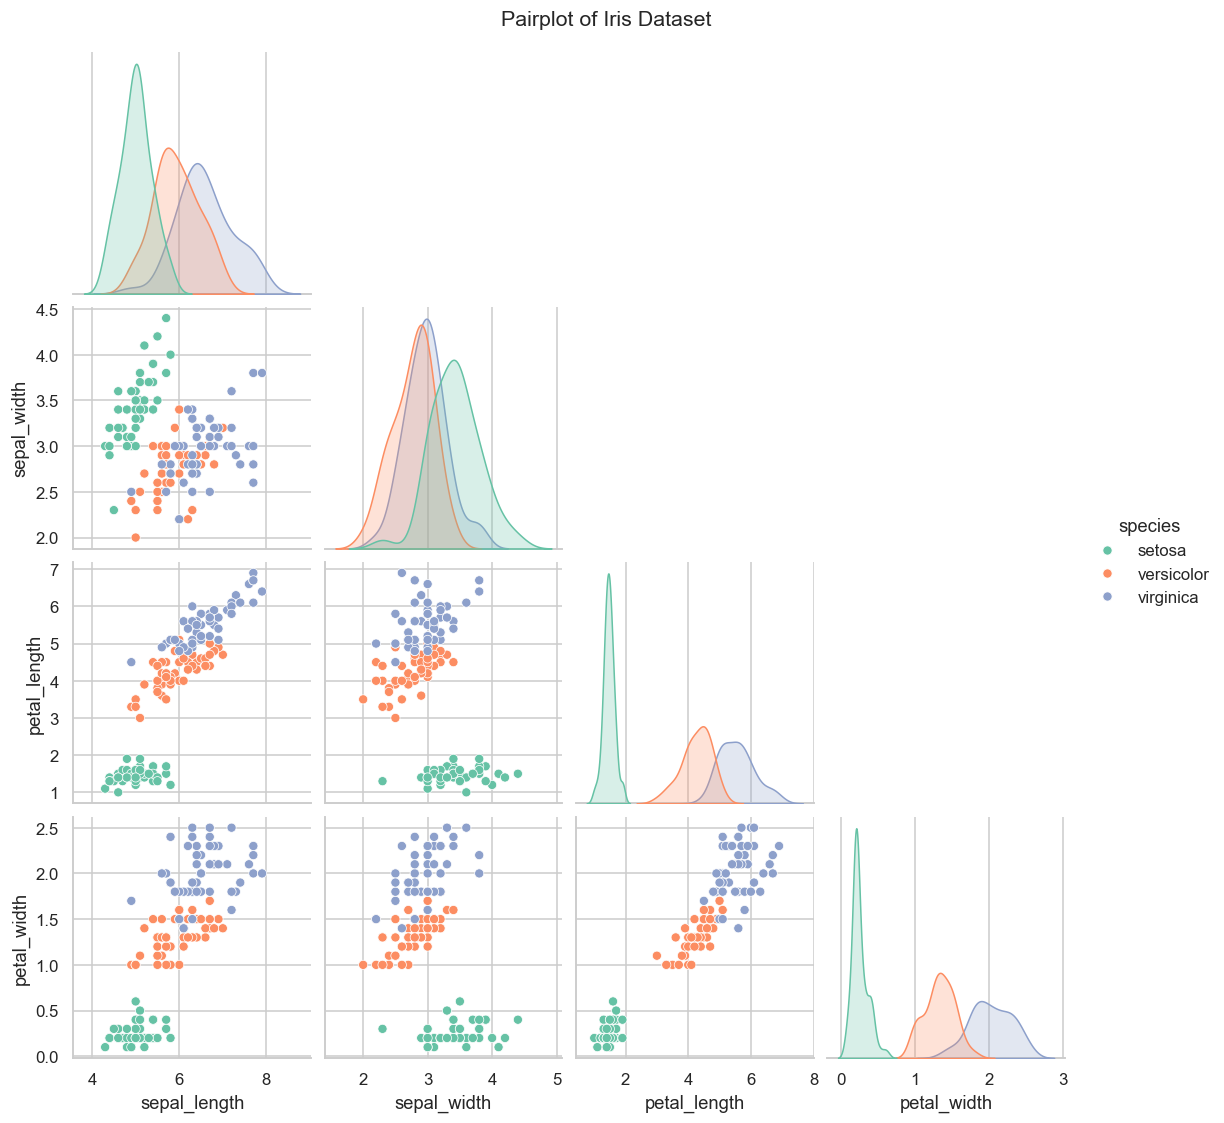

In [14]:
sns.pairplot(df, hue="species", palette="Set2", corner=True)
plt.suptitle("Pairplot of Iris Dataset", y=1.02, fontsize=14)
plt.show()


### 3.6 Heatmap – Feature Correlation

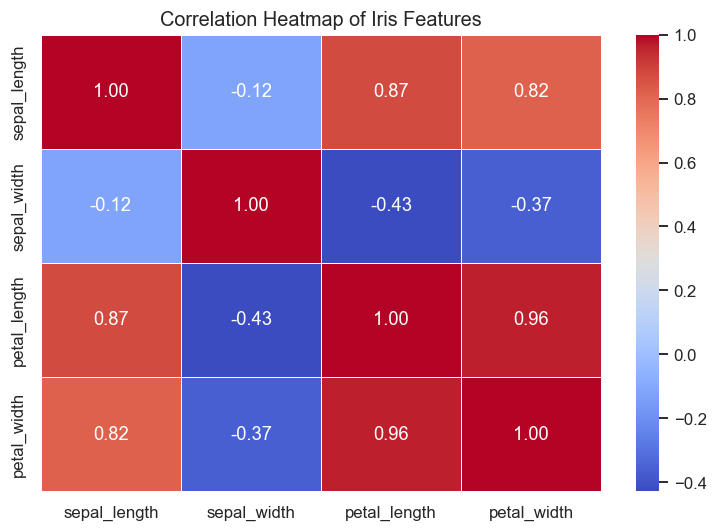

In [15]:
plt.figure(figsize=(7, 5))
corr = df.drop(columns="species").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Iris Features", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Conclusion

- **Dataset Structure:** The Iris dataset has 150 rows and 5 columns with no missing values. It is perfectly balanced with 50 samples per species.
- **Scatter Plots:** Petal length vs petal width shows clear separation between species — especially *setosa* which is distinctly clustered. Sepal dimensions show more overlap.
- **Histograms:** *Setosa* has notably smaller petal dimensions, while *virginica* has the largest. Sepal width is the most normally distributed feature.
- **Box Plots:** Minor outliers exist in sepal width for *setosa*. Overall, data is clean and well-structured.
- **Correlation:** Petal length and petal width are highly correlated (r = 0.96), making them the most useful features for classification.
- **Key Insight:** Petal measurements are far more discriminative than sepal measurements for distinguishing iris species.
